In [3]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [12]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.min = 0 # 最小弾数
        self.max = 0 # 最大弾数

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit or self.max-self.min>96000:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/349.9 * 0.45:
                self.kaitensuu = 0
                self.balls += 1400
                self.normal()
            elif x <= 1/349.9:
                self.kaitensuu = 0
                self.balls += 2800
                # 3/4で+0, 1/4で+1400, 1/16で+2800, 1/64で+4200, 1/256で+5600
                furiwake = random.random()
                if furiwake <= 0.75:
                    self.balls += 0
                elif furiwake <= 0.25:
                    self.balls += 1400
                elif furiwake <= 0.0625:
                    self.balls += 2800
                elif furiwake <= 0.015625:
                    self.balls += 4200
                elif furiwake <= 0.00390625:
                    self.balls += 5600
                self.rush()
    def rush(self):
        x = random.random()
        if x <= 0.76747669:
            furiwake = random.random()
            if furiwake <= 0.2:
                self.balls += 280
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            elif furiwake <= 0.75:
                self.balls += 1400
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            else:
                self.balls += 2800
                furiwake = random.random()
                if furiwake <= 0.75:
                    self.balls += 0
                elif furiwake <= 0.25:
                    self.balls += 1400
                elif furiwake <= 0.0625:
                    self.balls += 2800
                elif furiwake <= 0.015625:
                    self.balls += 4200
                elif furiwake <= 0.00390625:
                    self.balls += 5600
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
        else:
            self.normal()


In [ ]:
# results = []
# for i in tqdm(range(100)):
#     instance = spec(0, 0, 250, 20, 1000000)
#     a = instance.normal()
#     results.append(1000000*1000/a/4)
# print(np.mean(results))

100%|██████████| 100/100 [00:09<00:00, 10.12it/s]

16.719197274406994


In [15]:
result = []
for i in tqdm(range(100000)):
    instance = spec(0, 0, 0, 16, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


100%|██████████| 100000/100000 [00:26<00:00, 3744.33it/s]


平均収支:  -3101.49450625
標準偏差:  17501.204850258087
最大値:  122058.125
最小値:  -31265.625
5%点:  -25665.625
95%点:  30054.375


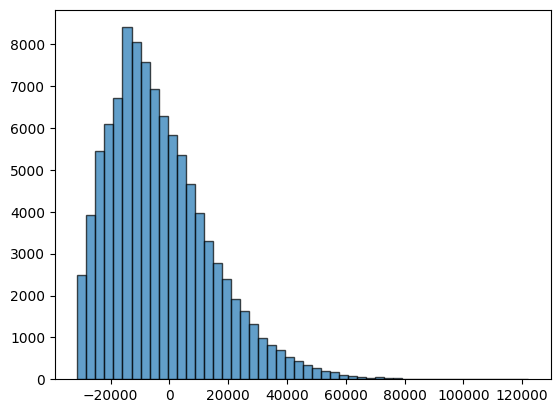

In [16]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()